In [1]:
# !/usr/bin/env python3
# -*- coding: utf-8 -*-

# =====================
# General utilities
# =====================
import json
import os
import pickle
import time
from collections import Counter

# =====================
# Data handling & processing
# =====================
import numpy as np
import pandas as pd
from tqdm import tqdm

# =====================
# Visualization
# =====================
import matplotlib.pyplot as plt
import seaborn as sns

# =====================
# Machine Learning - Core scikit-learn
# =====================
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score,
    root_mean_squared_error, roc_auc_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.svm import SVC, SVR

# =====================
# Machine Learning - Tree Boosting & advanced
# =====================
import xgboost as xg
import lightgbm as lgb
import catboost

# =====================
# Deep Learning - TensorFlow / Keras
# =====================
import tensorflow as tf
from keras import regularizers
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.optimizers import Adam

# =====================
# Deep Learning - PyTorch
# =====================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# =====================
# Imbalanced data handling
# =====================
from imblearn.over_sampling import SMOTE

# =====================
# Optimization / AutoML
# =====================
import optuna

# =====================
# Feature importance & explainability
# =====================
import shap

# =====================
# Self Made Utilities
# =====================
from utils import *

# =====================
# Settings & reproducibility
# =====================
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

print("Libraries successfully loaded. Ready to go!")

c:\Users\robkr\anaconda3\envs\ml-env-stable\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries successfully loaded. Ready to go!


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

feature_cols = [col for col in train.columns if col not in ['id', 'BeatsPerMinute']]
target_col = 'BeatsPerMinute'


🔗 CORRELATION ANALYSIS


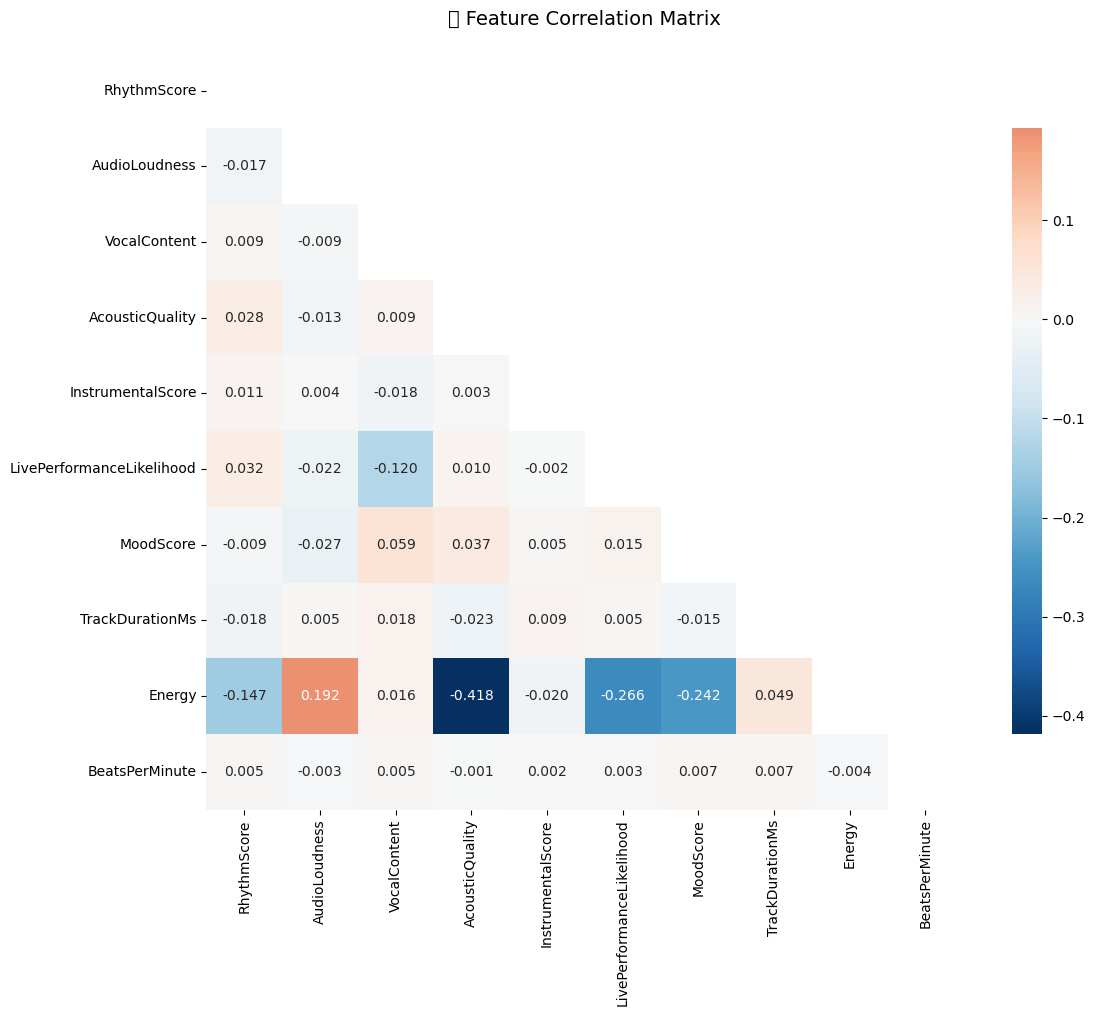


🎯 Features ranked by correlation with BPM:
 1. MoodScore                 | Correlation: 0.0071
 2. TrackDurationMs           | Correlation: 0.0066
 3. RhythmScore               | Correlation: 0.0054
 4. VocalContent              | Correlation: 0.0049
 5. Energy                    | Correlation: 0.0044
 6. LivePerformanceLikelihood | Correlation: 0.0035
 7. AudioLoudness             | Correlation: 0.0033
 8. InstrumentalScore         | Correlation: 0.0019
 9. AcousticQuality           | Correlation: 0.0008


In [3]:
print("\n" + "="*50)
print("🔗 CORRELATION ANALYSIS")
print("="*50)

# Calculate correlation matrix
correlation_matrix = train[feature_cols + [target_col]].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', 
            center=0, square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('🔗 Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Feature importance based on correlation with target
target_correlations = correlation_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
print("\n🎯 Features ranked by correlation with BPM:")
for i, (feature, corr) in enumerate(target_correlations.items(), 1):
    print(f"{i:2d}. {feature:<25} | Correlation: {corr:.4f}")

In [7]:
print("\n" + "="*50)
print("🧮 FEATURE ENGINEERING")
print("="*50)

def create_features(df):
    """Create additional features that might help predict BPM"""
    df = df.copy()
    
    # 1. Rhythm and Energy interactions
    df['RhythmEnergyProduct'] = df['RhythmScore'] * df['Energy']
    df['RhythmEnergyRatio'] = df['RhythmScore'] / (df['Energy'] + 1e-8)
    
    # 2. Audio characteristics
    df['LoudnessEnergyProduct'] = df['AudioLoudness'] * df['Energy']
    df['VocalInstrumentalRatio'] = df['VocalContent'] / (df['InstrumentalScore'] + 1e-8)
    
    # 3. Track duration features
    df['TrackDurationMin'] = df['TrackDurationMs'] / 60000  # Convert to minutes
    df['DurationMoodProduct'] = df['TrackDurationMin'] * df['MoodScore']
    
    # 4. Performance and quality features
    df['QualityPerformanceProduct'] = df['AcousticQuality'] * df['LivePerformanceLikelihood']
    
    # 5. Polynomial features for top correlated features
    top_3_features = target_correlations.head(3).index.tolist()
    for feature in top_3_features:
        df[f'{feature}_squared'] = df[feature] ** 2
        df[f'{feature}_sqrt'] = np.sqrt(np.abs(df[feature]))
    
    # 6. Binned features
    df['EnergyBin'] = pd.cut(df['Energy'], bins=5, labels=['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh'])
    df['RhythmBin'] = pd.cut(df['RhythmScore'], bins=5, labels=['VeryLow', 'Low', 'Medium', 'High', 'VeryHigh'])
    
    # 7. Interaction between rhythm and tempo-related features
    df['RhythmDurationInteraction'] = df['RhythmScore'] * df['TrackDurationMin']

    # 8. Log transformations
    #df['LogTrackDuration'] = np.log1p(df['TrackDurationMs'])
    #df['LogLoudness'] = np.log1p(np.abs(df['AudioLoudness']) + 1e-8)  # Avoid log(0)
    
    return df

# Apply feature engineering
train_engineered = create_features(train)

# Get new feature columns
new_features = [col for col in train_engineered.columns if col not in train.columns]
print(f"✨ Created {len(new_features)} new features:")
for feature in new_features:
    print(f"   • {feature}")


🧮 FEATURE ENGINEERING
✨ Created 16 new features:
   • RhythmEnergyProduct
   • RhythmEnergyRatio
   • LoudnessEnergyProduct
   • VocalInstrumentalRatio
   • TrackDurationMin
   • DurationMoodProduct
   • QualityPerformanceProduct
   • MoodScore_squared
   • MoodScore_sqrt
   • TrackDurationMs_squared
   • TrackDurationMs_sqrt
   • RhythmScore_squared
   • RhythmScore_sqrt
   • EnergyBin
   • RhythmBin
   • RhythmDurationInteraction


In [8]:
# Analyze correlations with new features
numerical_features = train_engineered.select_dtypes(include=[np.number]).columns
numerical_features = [col for col in numerical_features if col not in ['id']]

new_correlations = train_engineered[numerical_features].corr()[target_col].drop(target_col).abs().sort_values(ascending=False)

print(f"\n🔥 Top 15 Features by Correlation with BPM:")
for i, (feature, corr) in enumerate(new_correlations.head(15).items(), 1):
    print(f"{i:2d}. {feature:<30} | Correlation: {corr:.4f}")


🔥 Top 15 Features by Correlation with BPM:
 1. DurationMoodProduct            | Correlation: 0.0099
 2. RhythmDurationInteraction      | Correlation: 0.0088
 3. MoodScore_squared              | Correlation: 0.0082
 4. MoodScore                      | Correlation: 0.0071
 5. TrackDurationMs                | Correlation: 0.0066
 6. TrackDurationMin               | Correlation: 0.0066
 7. TrackDurationMs_sqrt           | Correlation: 0.0066
 8. TrackDurationMs_squared        | Correlation: 0.0065
 9. MoodScore_sqrt                 | Correlation: 0.0061
10. RhythmScore_sqrt               | Correlation: 0.0057
11. RhythmScore                    | Correlation: 0.0054
12. VocalContent                   | Correlation: 0.0049
13. RhythmScore_squared            | Correlation: 0.0049
14. Energy                         | Correlation: 0.0044
15. LivePerformanceLikelihood      | Correlation: 0.0035


In [9]:
print("\n" + "="*50)
print("🤖 MODEL DEVELOPMENT")
print("="*50)

# Prepare features for modeling
feature_columns = [col for col in numerical_features if col != target_col]
X = train_engineered[feature_columns]
y = train_engineered[target_col]

print(f"📊 Training with {len(feature_columns)} features")
print(f"🎯 Target variable: {target_col}")

# Split the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


🤖 MODEL DEVELOPMENT
📊 Training with 23 features
🎯 Target variable: BeatsPerMinute


In [11]:
def objective_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 5.0),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'random_state': 42,
        'eval_metric': 'rmse',
        'early_stopping_rounds': 100,
        'verbosity': 0
    }

    # 5-fold CV for faster tuning
    cv_scores = []
    kf_tune = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, val_idx in kf_tune.split(X, y):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

        model = xg.XGBRegressor(**params)
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)

        pred = model.predict(X_val_fold)
        score = root_mean_squared_error(y_val_fold, pred)
        cv_scores.append(score)

    return np.mean(cv_scores)

print("➗ Tuning XGBoost parameters...")
study_xgboost = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))       
study_xgboost.optimize(objective_xgboost, n_trials=50)

best_xgboost_params = study_xgboost.best_params
print(f"Best XGBoost CV RMSE: {study_xgboost.best_value:.4f}")
print(f"Best XGBoost params: {best_xgboost_params}")

[I 2025-09-22 16:55:33,630] A new study created in memory with name: no-name-2613cc62-6b6d-429c-b6db-a352f7ccf2ab


➗ Tuning XGBoost parameters...


[I 2025-09-22 16:55:47,274] Trial 0 finished with value: 26.46286553542466 and parameters: {'n_estimators': 193, 'learning_rate': 0.09556428757689246, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.5624074561769746, 'colsample_bytree': 0.562397808134481, 'reg_alpha': 0.21035886311957896, 'reg_lambda': 4.46470458309974, 'gamma': 0.6011150117432088}. Best is trial 0 with value: 26.46286553542466.
[I 2025-09-22 16:56:13,665] Trial 1 finished with value: 26.461259339920947 and parameters: {'n_estimators': 357, 'learning_rate': 0.011852604486622221, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.5849356442713105, 'colsample_bytree': 0.5727299868828403, 'reg_alpha': 0.4484685687215243, 'reg_lambda': 2.216968971838151, 'gamma': 0.5247564316322378}. Best is trial 1 with value: 26.461259339920947.
[I 2025-09-22 16:56:29,414] Trial 2 finished with value: 26.46090325666113 and parameters: {'n_estimators': 222, 'learning_rate': 0.036210622617823776, 'max_depth': 6, 'min_child_weight'

Best XGBoost CV RMSE: 26.4598
Best XGBoost params: {'n_estimators': 408, 'learning_rate': 0.02232626922613817, 'max_depth': 4, 'min_child_weight': 6, 'subsample': 0.6265282602544591, 'colsample_bytree': 0.5451089059390968, 'reg_alpha': 0.20080755864017114, 'reg_lambda': 3.2027441146025515, 'gamma': 0.06383958200431228}


In [10]:
best_xgb_params = {'n_estimators': 408, 'learning_rate': 0.02232626922613817, 'max_depth': 4, 'min_child_weight': 6, 'subsample': 0.6265282602544591, 'colsample_bytree': 0.5451089059390968, 'reg_alpha': 0.20080755864017114, 'reg_lambda': 3.2027441146025515, 'gamma': 0.06383958200431228}

In [12]:
def objective_lightgbm(trial):
    # LightGBM-specific parameter space for regression
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 500),       
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),   
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'num_leaves': trial.suggest_int('num_leaves', 31, 127),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 2.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'random_state': 42,
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'early_stopping_rounds': 100
    }

    # 5-fold CV for faster tuning
    cv_scores = []
    kf_tune = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, val_idx in kf_tune.split(X, y):
        X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
        X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)])

        pred = model.predict(X_val_fold)
        score = root_mean_squared_error(y_val_fold, pred)
        cv_scores.append(score)

    return np.mean(cv_scores)

print("Tuning LightGBM parameters...")
study_lightgbm = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_lightgbm.optimize(objective_lightgbm, n_trials=50)

best_lightgbm_params = study_lightgbm.best_params
print(f"Best LightGBM CV RMSE: {study_lightgbm.best_value:.4f}")
print(f"Best LightGBM params: {best_lightgbm_params}")

[I 2025-09-22 17:10:13,541] A new study created in memory with name: no-name-ae66fb6a-a697-44cd-b19c-10be42431a88


Tuning LightGBM parameters...


[I 2025-09-22 17:10:22,286] Trial 0 finished with value: 26.461120616900757 and parameters: {'n_estimators': 193, 'learning_rate': 0.09556428757689246, 'max_depth': 7, 'num_leaves': 89, 'min_child_samples': 32, 'subsample': 0.7467983561008608, 'colsample_bytree': 0.7174250836504598, 'reg_alpha': 1.7323522915498704, 'reg_lambda': 1.2022300234864176, 'min_split_gain': 0.7080725777960455}. Best is trial 0 with value: 26.461120616900757.
[I 2025-09-22 17:10:25,990] Trial 1 finished with value: 26.460236753426038 and parameters: {'n_estimators': 20, 'learning_rate': 0.0972918866945795, 'max_depth': 7, 'num_leaves': 51, 'min_child_samples': 34, 'subsample': 0.7550213529560301, 'colsample_bytree': 0.7912726728878613, 'reg_alpha': 1.0495128632644757, 'reg_lambda': 0.8638900372842315, 'min_split_gain': 0.2912291401980419}. Best is trial 1 with value: 26.460236753426038.
[I 2025-09-22 17:10:38,628] Trial 2 finished with value: 26.459448764065314 and parameters: {'n_estimators': 310, 'learning_ra

Best LightGBM CV RMSE: 26.4589
Best LightGBM params: {'n_estimators': 462, 'learning_rate': 0.05117655911111268, 'max_depth': 5, 'num_leaves': 41, 'min_child_samples': 47, 'subsample': 0.7419521727949605, 'colsample_bytree': 0.951693024176909, 'reg_alpha': 0.9338285054829394, 'reg_lambda': 0.9192058094718278, 'min_split_gain': 0.5526297840797338}


In [11]:
best_lightgbm_params = {'n_estimators': 462, 'learning_rate': 0.05117655911111268, 'max_depth': 5, 'num_leaves': 41, 'min_child_samples': 47, 'subsample': 0.7419521727949605, 'colsample_bytree': 0.951693024176909, 'reg_alpha': 0.9338285054829394, 'reg_lambda': 0.9192058094718278, 'min_split_gain': 0.5526297840797338}

In [12]:
X_test = create_features(test)[feature_columns]
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Define the ensemble models (these need to be trained first)
best_models = {
    'XGBoost': xg.XGBRegressor(**best_xgb_params, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(**best_lightgbm_params, random_state=42, n_jobs=-1, force_row_wise=True),
    'Ridge': Ridge(alpha=1.0)
}

# Train the models on full training data
print("Training ensemble models on full dataset...")

# Train XGBoost
best_models['XGBoost'].fit(X_train, y_train)

best_models['LightGBM'].fit(X_train, y_train)

# Train Ridge (using scaled features)
X_train_scaled = scaler.fit_transform(X_train)
best_models['Ridge'].fit(X_train_scaled, y_train)

# Make predictions using ensemble
weights = {'XGBoost': 0.4, 'Ridge': 0.4, 'LightGBM': 0.2} 
test_predictions = np.zeros(len(X_test))

print("Making ensemble predictions...")

for model_name, model in best_models.items():
    weight = weights[model_name]
    
    if model_name == 'Ridge':
        # Ridge uses scaled features
        X_test_scaled = scaler.transform(X_test)
        pred = model.predict(X_test_scaled)
    else:
        # XGBoost and LGBM use original features
        pred = model.predict(X_test)
    
    test_predictions += weight * pred
    print(f"   {weight*100:2.0f}% {model_name} predictions added")

# Create submission DataFrame
submission = pd.DataFrame({
    'id': test['id'],
    'BeatsPerMinute': test_predictions
})

print(f"\n✅ Submission created with {len(submission)} predictions")
print(f"Prediction range: {test_predictions.min():.2f} - {test_predictions.max():.2f}")

rmse = np.sqrt(mean_squared_error(y_val, (weights['XGBoost'] * best_models['XGBoost'].predict(X_val) + weights['Ridge'] * best_models['Ridge'].predict(X_val_scaled) + weights['LightGBM'] * best_models['LightGBM'].predict(X_val))))
print(f"Ensemble Validation RMSE: {rmse:.4f}")

Training ensemble models on full dataset...
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 419331, number of used features: 23
[LightGBM] [Info] Start training from score 119.056554
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

In [ ]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = {name: np.zeros(len(X_train)) for name in best_models}
test_preds = {name: np.zeros(len(X_test)) for name in best_models}

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Ridge needs scaled features
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    for name, model in best_models.items():
        m = model  # fresh model each fold
        if name == 'Ridge':
            m.fit(X_tr_scaled, y_tr)
            oof_preds[name][val_idx] = m.predict(X_val_scaled)
            test_preds[name] += m.predict(X_test_scaled) / kf.n_splits
        else:
            m.fit(X_tr, y_tr)
            oof_preds[name][val_idx] = m.predict(X_val)
            test_preds[name] += m.predict(X_test) / kf.n_splits

# Stack into meta-features
oof_stack = np.column_stack([oof_preds[name] for name in best_models])
test_stack = np.column_stack([test_preds[name] for name in best_models])

# Fit a meta-model (learn weights automatically)
meta_model = LinearRegression()
meta_model.fit(oof_stack, y_train)

val_rmse = np.sqrt(mean_squared_error(y_train, meta_model.predict(oof_stack)))
print("Stacking Ensemble CV RMSE:", val_rmse)

# Final test predictions
final_preds = meta_model.predict(test_stack)

[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 335464, number of used features: 23
[LightGBM] [Info] Start training from score 119.062610
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

Exception ignored on calling ctypes callback function: <function _log_callback at 0x0000025BE862F740>
Traceback (most recent call last):
  File "c:\Users\robkr\anaconda3\envs\ml-env-stable\Lib\site-packages\lightgbm\basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
    
KeyboardInterrupt: 


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

In [16]:
submission.to_csv('ensemble-1.csv', index=False)

submission.head()

,id,BeatsPerMinute
0,524164,118.964223
1,524165,118.880376
2,524166,119.633274
3,524167,119.412212
4,524168,119.623687


In [17]:
submission2 = pd.read_csv("best_public-1.csv")

# Step 3: Ensemble the two
ensemble = submission.merge(submission2, on="id", suffixes=("_1", "_2"))
ensemble["BeatsPerMinute"] = 0.01 * ensemble["BeatsPerMinute_1"] + 0.99 * ensemble["BeatsPerMinute_2"]

# Step 4: Save final blended submission
final = ensemble[["id", "BeatsPerMinute"]]
final.to_csv("submission1.csv", index=False)

print("✅ Ensemble submission saved as ensemble.csv")
print(f"🎯 BPM range: {final['BeatsPerMinute'].min():.2f} - {final['BeatsPerMinute'].max():.2f}")

✅ Ensemble submission saved as ensemble.csv
🎯 BPM range: 97.37 - 150.82
